In [40]:
# @title
import pandas as pd

clients = pd.read_csv('clients.csv')
properties = pd.read_csv('properties.csv')

clients.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [17]:
clients.columns

Index(['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth',
       'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel'],
      dtype='object')

In [18]:
clients.isnull().sum()

,0
client_id,0
client_type,0
first_name,0
last_name,0
date_of_birth,0
gender,0
country,0
region,0
acquisition_purpose,0
satisfaction_score,0


In [19]:
clients = clients.drop_duplicates()

In [20]:
clients = clients.fillna(method='ffill')

/tmp/ipykernel_40266/832310432.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  clients = clients.fillna(method='ffill')


In [21]:
clients.isnull().sum()

,0
client_id,0
client_type,0
first_name,0
last_name,0
date_of_birth,0
gender,0
country,0
region,0
acquisition_purpose,0
satisfaction_score,0


In [22]:
from sklearn.preprocessing import LabelEncoder

In [23]:
le = LabelEncoder()

In [24]:
clients['client_type'] = le.fit_transform(clients['client_type'])
clients['acquisition_purpose'] = le.fit_transform(clients['acquisition_purpose'])
clients['region'] = le.fit_transform(clients['region'])
clients['country'] = le.fit_transform(clients['country'])
clients['referral_channel'] = le.fit_transform(clients['referral_channel'])

In [25]:
clients.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,1,Kareem,Liu,05-11-1968,F,9,8,0,4,Yes,2
1,C0002,1,Trystan,Oconnor,11/26/1962,M,9,8,0,1,No,2
2,C0003,1,Kale,Gay,04-07-1959,M,9,8,0,4,Yes,0
3,C0004,1,Russell,Gross,11/25/1959,M,9,8,0,5,No,2
4,C0005,0,Marleez,Co,2/28/1976,M,9,8,1,5,No,2


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(clients.select_dtypes(include=['int64','float64']))

In [27]:
from sklearn.cluster import KMeans

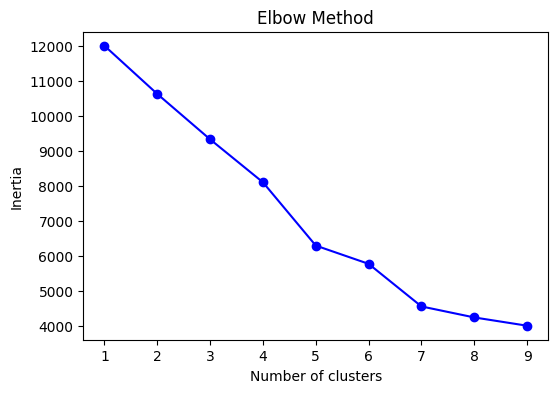

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Elbow method
inertia = []
K = range(1,10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [29]:
kmeans = KMeans(n_clusters=4, random_state=42)
clients['cluster'] = kmeans.fit_predict(scaled_data)

clients['cluster'].value_counts()

,count
cluster,
0,606
3,589
1,419
2,386


In [32]:
numeric_cols = clients.select_dtypes(include=['int64','float64']).columns
cluster_summary = clients.groupby('cluster')[numeric_cols].mean()
cluster_summary

,client_type,country,region,acquisition_purpose,satisfaction_score,referral_channel
cluster,,,,,,
0,0.942244,7.985149,20.391089,1.00000,3.036304,1.179868
1,0.959427,6.935561,43.990453,0.02148,3.124105,1.217184
2,0.958549,8.375648,11.466321,0.00000,4.531088,1.212435
3,0.940577,8.261460,12.315789,0.00000,1.969440,1.196944


In [33]:
!pip install streamlit --quiet

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 108.3 MB/s eta 0:00:00


In [34]:
st.title("Buyer Segmentation Dashboard - Parcl Real Estate")

st.write("This dashboard shows buyer clusters and their investment patterns.")

2026-04-01 14:50:57.937 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:50:58.108 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-01 14:50:58.109 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:50:58.110 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:50:58.112 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:50:58.113 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:50:58.115 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [35]:
st.subheader("Cluster Distribution")

cluster_counts = clients['cluster'].value_counts()
st.bar_chart(cluster_counts)

2026-04-01 14:51:24.910 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:51:24.911 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:51:24.913 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:51:26.989 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:51:26.991 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:51:26.991 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

2026-04-01 14:51:43.331 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:51:43.332 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:51:43.333 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:51:43.398 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:51:43.519 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:51:43.520 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:51:43.521 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

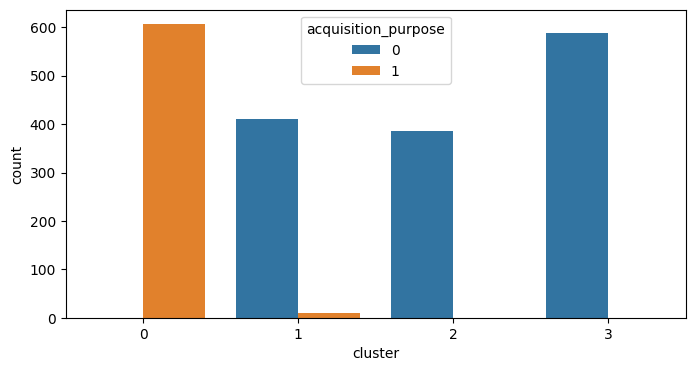

In [36]:
st.subheader("Investment Patterns by Cluster")

fig, ax = plt.subplots(figsize=(8,4))
sns.countplot(x='cluster', hue='acquisition_purpose', data=clients, ax=ax)
st.pyplot(fig)

In [37]:
st.subheader("Geographic Buyer Analysis")

fig, ax = plt.subplots(figsize=(8,4))
sns.countplot(x='region', hue='cluster', data=clients, ax=ax)
st.pyplot(fig)

2026-04-01 14:52:05.520 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:52:05.521 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:52:05.523 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:52:05.759 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:52:06.068 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:52:06.069 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:52:06.070 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [38]:
st.subheader("Cluster Insights (Average Numeric Features)")

numeric_cols = clients.select_dtypes(include=['int64','float64']).columns
cluster_summary = clients.groupby('cluster')[numeric_cols].mean()
st.dataframe(cluster_summary)

2026-04-01 14:52:21.309 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:52:21.310 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:52:21.312 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:52:21.319 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:52:21.320 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:52:21.320 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [39]:
!streamlit run your_notebook_name.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: your_notebook_name.py
